In [6]:
import sys,os,re,argparse,glob
import pandas as pd
from scipy.io import loadmat
from pathlib import Path
import matplotlib.pyplot as plt
from pctk import multicellds
import numpy as np

In [7]:
base_path = "/home/tntiniak/Work/observatory_benchmark/PhysiCell/results/decay_study/"
folders = ["size_5", "size_10", "size_20", "size_40"]

In [8]:

# analytical solution
dt_analytical = [ 0.,0.52631579,1.05263158,1.57894737,2.10526316,2.63157895
,3.15789474,3.68421053,4.21052632,4.73684211,5.26315789,5.78947368
,6.31578947,6.84210526,7.36842105,7.89473684,8.42105263,8.94736842
,9.47368421,10.]

dif_analytical = [10.,7.79217467,7.1711064, 6.96508102,6.89482579,6.87071343
,6.86242517,6.85957518,6.8585951, 6.85825806,6.85814215,6.85810229
,6.85808858,6.85808387,6.85808224,6.85808169,6.8580815, 6.85808143
,6.85808141,6.8580814 ]



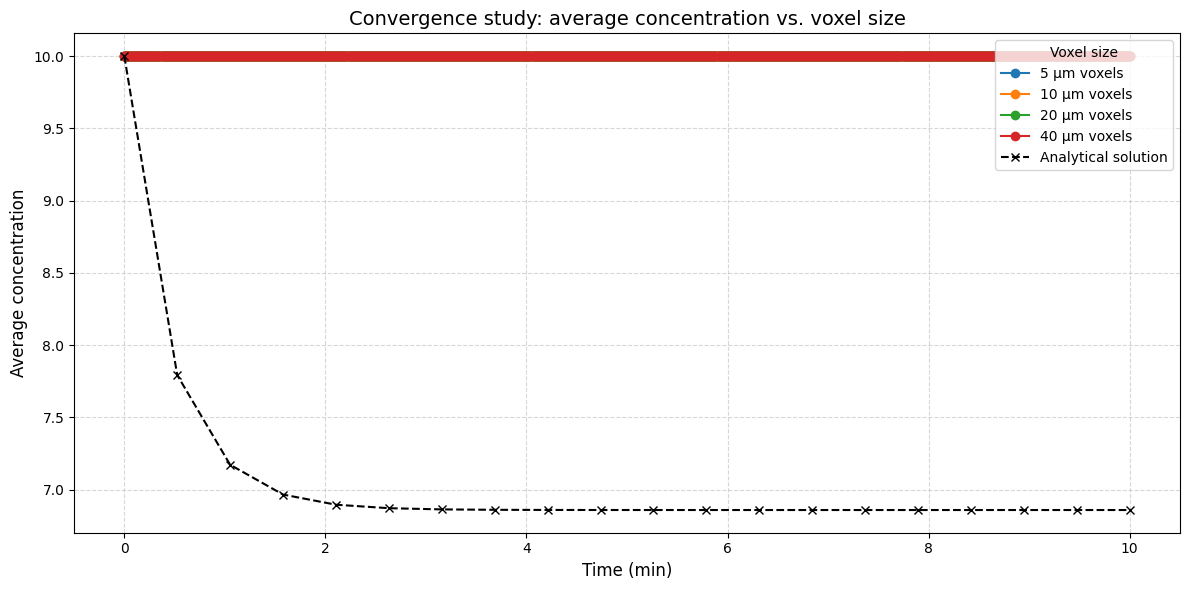

In [9]:
# --- settings ---

dt = 0.01   # minutes per time step
zoom_end = 50  # minutes

# prepare full-range figure
fig, ax = plt.subplots(figsize=(12, 6))
global_max = 0.0
series_by_label = {}

for folder in folders:
    # parse voxel size dh
    dh = float(folder.split("_")[1])

    # open that simulation
    sim_path = os.path.join(base_path, folder)
    reader   = multicellds.MultiCellDS(output_folder=sim_path)

    # collect central‐voxel averages
    mean    = []

    for t, a in reader.microenvironment_as_matrix_iterator():
        arr_flat = a[4]  # flattened concentration

        # average those central voxels
        mean.append(arr_flat.mean())

    # build a matching time vector
    times = np.arange(len(mean)) * dt

    # wrap in a Series and plot
    label = f"{int(dh)} μm voxels"
    series = pd.Series([x / 602.2 for x in mean],
                       index=pd.Index(times, name="Time (min)"),
                       name=label)
    series.plot(ax=ax, marker='o', linestyle='-', label=label)

    # store for zoom plot
    series_by_label[label] = series

    # track global max for y-limit
    global_max = max(global_max, series.max())

# finalize full-range plot
# ax.set_ylim(0, global_max * 1.05)
# PLOT ANALYTICAL SOLUTION ON TOP
ax.plot(dt_analytical,dif_analytical, label="Analytical solution", color='black', linestyle='--', marker='x')
ax.set_xlabel("Time (min)", fontsize=12)
ax.set_ylabel("Average concentration", fontsize=12)
ax.set_title("Convergence study: average concentration vs. voxel size", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(title="Voxel size", loc="upper right")

plt.tight_layout()
plt.show()

# zoomed plot: first 50 minutes


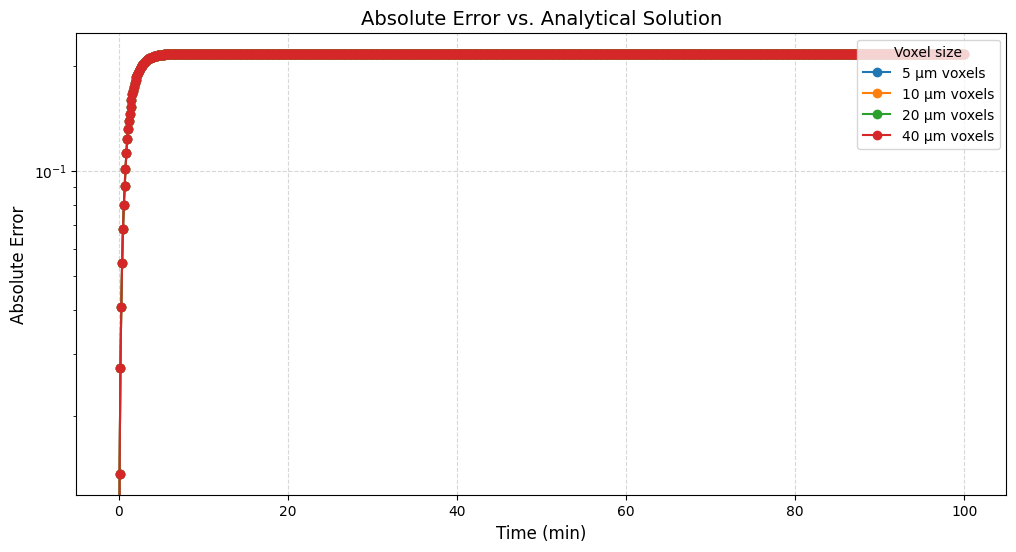

In [10]:
# --- Calculate absolute error with analytical solution ---

# analytical solution time points and values
dt_analytical = [0., 0.52631579, 1.05263158, 1.57894737, 2.10526316, 2.63157895,
                 3.15789474, 3.68421053, 4.21052632, 4.73684211, 5.26315789, 5.78947368,
                 6.31578947, 6.84210526, 7.36842105, 7.89473684, 8.42105263, 8.94736842,
                 9.47368421, 10.]
dif_analytical = [10., 9.92815197, 9.87126486, 9.83518508, 9.81375256, 9.80121673, 
                  9.79391127, 9.78965756, 9.78718127, 9.78573979, 9.78490068, 9.78441223,
                  9.78412789, 9.78396238, 9.78386603, 9.78380995, 9.7837773, 9.7837583,
                  9.78374724, 9.7837408]

# convert analytical solution to Series for interpolation
analytical_series = pd.Series(dif_analytical, index=dt_analytical)

# prepare figure for absolute error plot
fig_error, ax_error = plt.subplots(figsize=(12, 6))
error_series_by_label = {}
dt = 0.1  # minutes per time step

for folder in folders:
    # parse voxel size dh
    dh = float(folder.split("_")[1])

    # open that simulation
    sim_path = os.path.join(base_path, folder)
    reader = multicellds.MultiCellDS(output_folder=sim_path)

    # collect central-voxel averages
    mean = []

    for t, a in reader.microenvironment_as_matrix_iterator():
        arr_flat = a[4]  # flattened concentration
        mean.append(arr_flat.mean())

    # build a matching time vector
    times = np.arange(len(mean)) * dt

    # create simulation series (convert to same units as analytical)
    sim_series = pd.Series([x / 602.2 for x in mean], index=times)

    # interpolate analytical solution to match simulation time points
    analytical_interp = np.interp(times, dt_analytical, dif_analytical)
    
    # calculate absolute error
    abs_error = np.abs(sim_series.values - analytical_interp)
    
    # create error series
    label = f"{int(dh)} μm voxels"
    error_series = pd.Series(abs_error, index=times, name=label)
    error_series_by_label[label] = error_series
    
    # plot
    error_series.plot(ax=ax_error, marker='o', linestyle='-', label=label)

# finalize error plot

ax_error.set_xlabel("Time (min)", fontsize=12)
ax_error.set_ylabel("Absolute Error", fontsize=12)
ax_error.set_title("Absolute Error vs. Analytical Solution", fontsize=14)
ax_error.grid(True, linestyle="--", alpha=0.5)
ax_error.legend(title="Voxel size", loc="upper right")
ax_error.set_yscale('log')  # log scale to see differences better



In [11]:
dt_analytical_center = [ 0.,0.52631579,1.05263158,1.57894737,2.10526316,2.63157895
,3.15789474,3.68421053,4.21052632,4.73684211,5.26315789,5.78947368
,6.31578947,6.84210526,7.36842105,7.89473684,8.42105263,8.94736842
,9.47368421,10.]
diff_analytical_center = [10.,7.83908758,7.49652531,7.34117386,7.25600623,7.20713235
,7.17877842,7.16228652,7.15268824,7.14710124,7.14384902,7.14195589
,7.14085387,7.14021238,7.13983896,7.13962159,7.13949506,7.1394214
,7.13937852,7.13935357]

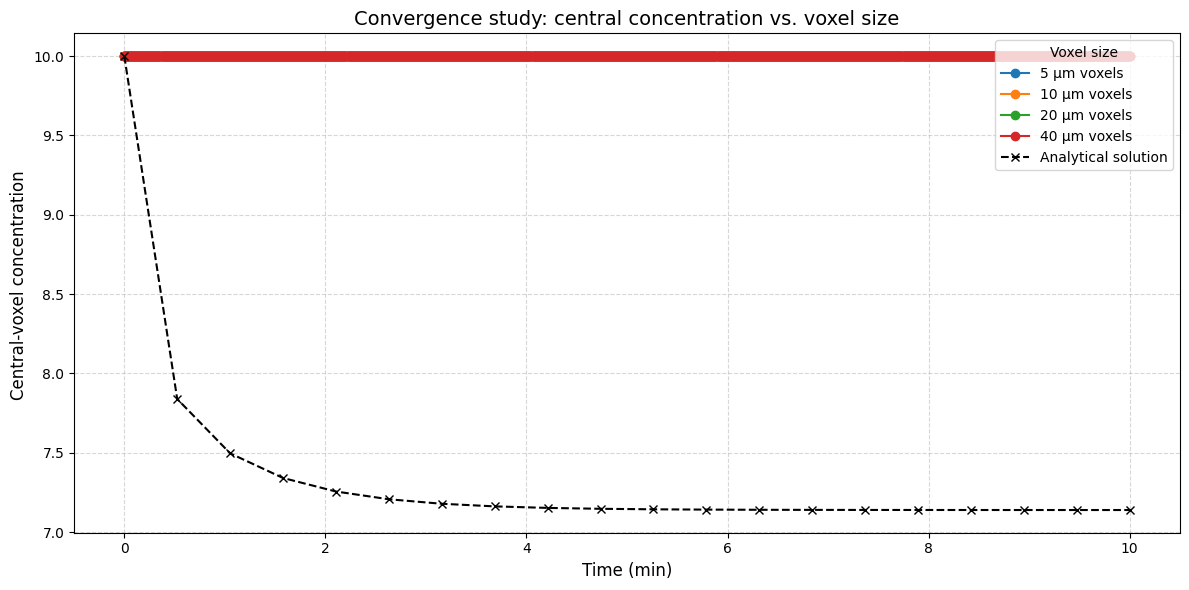

In [12]:
# now plot the concentation on the central voxels
# --- settings ---

from itertools import product


dt        = 0.01   # minutes per time step

# prepare figure
fig, ax = plt.subplots(figsize=(12, 6))
global_max = 0.0

for folder in folders:
    # parse voxel size dh
    dh = float(folder.split("_")[1])

    # open that simulation
    sim_path = os.path.join(base_path, folder)
    reader   = multicellds.MultiCellDS(output_folder=sim_path)

    # collect central‐voxel averages
    center_indices = None
    center_vals    = []

    for t, a in reader.microenvironment_as_matrix_iterator():
        arr_flat = a[4]  # flattened concentration

        if center_indices is None:
            # infer n and dims
            n_vox = arr_flat.size
            n     = int(round(n_vox**(1/3)))
            dims  = (n, n, n)

            # pick 1 or 2 mids per axis
            mids = []
            for d in dims:
                if d % 2 == 1:
                    mids.append([d//2])
                else:
                    mids.append([d//2 - 1, d//2])

            # build all center coords and flatten
            center_coords  = list(product(*mids))
            coords_arr     = np.array(center_coords).T
            center_indices = np.ravel_multi_index(coords_arr, dims)
            center_count   = len(center_indices)
        # average those central voxels
        vals = arr_flat[center_indices]
        center_vals.append(vals.mean())

    # build a matching time vector
    N     = len(center_vals)
    times = np.arange(N) * dt

    # wrap in a Series and plot
    label = f"{int(dh)} μm voxels"
    series = pd.Series([x/602.2 for x in center_vals],
                       index=pd.Index(times, name="Time (min)"),
                       name=label)
    series.plot(ax=ax, marker='o', linestyle='-')

    # track global max for y-limit
    global_max = max(global_max, series.max())
ax.plot(dt_analytical_center,diff_analytical_center, label="Analytical solution", color='black', linestyle='--', marker='x')

# finalize plot
ax.set_xlabel("Time (min)", fontsize=12)
ax.set_ylabel("Central-voxel concentration ", fontsize=12)
ax.set_title("Convergence study: central concentration vs. voxel size", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(title="Voxel size", loc="upper right")

plt.tight_layout()
plt.show()